<a href="https://colab.research.google.com/github/NicoleAlverga/Trilha/blob/main/C%C3%B3pia_de_perceptron_e_decision_tree_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Perceptron com NumPy + 🌲 Árvore de Decisão no Titanic

Neste notebook você vai:

1. **Implementar um Perceptron do zero** usando apenas `numpy` (sem `scikit-learn` para o modelo).
2. **(Desafio opcional)** Analisar o dataset **Titanic** e treinar um modelo de **Árvore de Decisão** (`DecisionTreeClassifier`).

> 💡 Complete os trechos marcados com `# TODO:` e execute as células na ordem. Mãos à obra!

# Parte 1 — Perceptron do zero com NumPy

## 🧩 O que é o Perceptron?

O Perceptron é um **classificador linear binário**. Para uma entrada $x$ (vetor de características), ele calcula uma combinação linear:

$$z = w \cdot x + b = \sum_{i} w_i\, x_i + b$$

e aplica uma **função degrau** para decidir a classe:

$$\hat{y} = \begin{cases} 1, & \text{se } z \ge 0 \\ 0, & \text{caso contrário} \end{cases}$$

**Regra de aprendizado:** para cada amostra, se houver erro $e = y - \hat{y}$, atualizamos:

$$w \leftarrow w + \eta\, e\, x$$

$$b \leftarrow b + \eta\, e$$

onde $\eta$ é a **taxa de aprendizado** (*learning rate*).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)

In [ ]:
# Gera um dataset sintético LINEARMENTE SEPARÁVEL com 2 características
n = 100

# Classe 0
X0 = np.random.normal(loc=[2.0, 2.0], scale=1.0, size=(n, 2))

# Classe 1
X1 = np.random.normal(loc=[7.0, 7.0], scale=1.0, size=(n, 2))

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes:", np.unique(y))

Formato de X: (200, 2)
Formato de y: (200,)
Classes: [0. 1.]


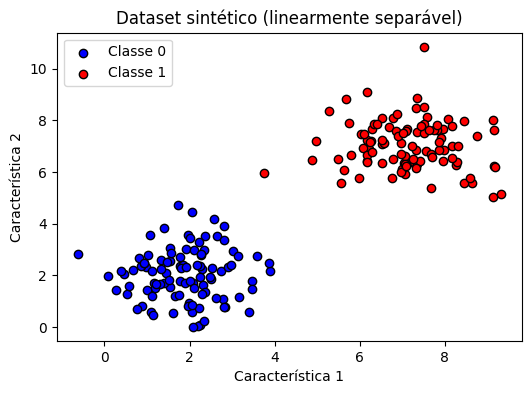

In [ ]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', edgecolors='k')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Dataset sintético (linearmente separável)')
plt.legend()
plt.show()

## ✍️ Sua tarefa: implementar o Perceptron

Implemente a classe abaixo **do zero**. Você precisa escrever:

1. **`_step`** — função degrau: retorne `1` se `x >= 0`, senão `0`.
2. **`fit`** — o treinamento:
   - inicialize `self.weights` e `self.bias`;
   - para cada época, percorra todas as amostras;
   - calcule a predição e o erro `erro = y - y_pred`;
   - se houver erro, atualize pesos e bias com a regra do Perceptron.
3. **`predict`** — calcule a saída linear $z = X \cdot w + b$ e aplique a função degrau em cada linha.

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.1, n_epochs=50):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None

    def _step(self, x):
       # TODO 1: implemente a função degrau (0/1)
        return 1 if x >= 0 else 0
        raise NotImplementedError

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # TODO 2a: inicialize self.weights e self.bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # TODO 2b: laço de treinamento
        #   - para cada época:
        #       - percorra as amostras (xi, yi)
        #       - calcule a predição
        #       - calcule o erro
        #       - se houver erro, atualize pesos e bias
        for _ in range(self.n_epochs):
           for xi, yi in zip(X, y):
            linear_output = np.dot(xi, self.weights) + self.bias
            prediction = self._step(linear_output)
            error = yi - prediction

            if error != 0:
                self.weights += self.learning_rate * error * xi
                self.bias += self.learning_rate * error

        return self

    def predict(self, X):
        # TODO 3: saída linear + função degrau em todas as linhas
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self._step(x) for x in linear_output])

        raise NotImplementedError

## 💡 Checklist de funções úteis

- `np.zeros(...)` para inicializar pesos.
- `np.dot(...)` (ou o operador `@`) para o produto escalar / matriz-vetor.
- `zip(X, y)` para percorrer amostra e rótulo juntos.
- Conversão booleana → inteiro: `(z >= 0).astype(int)`.

Pense nos **formatos**: `X` é `(n_amostras, n_features)`, `self.weights` deve ter `n_features` elementos e `self.bias` é um escalar.

In [ ]:
# ============================================================
# TODO: treine e avalie o seu Perceptron
# ============================================================
# 1. Instancie a classe Perceptron (escolha learning_rate e n_epochs)
model = Perceptron(learning_rate=0.1, n_epochs=50)
# 2. Treine com model.fit(X, y)
model.fit(X, y)
# 3. Faça predições com model.predict(X)
y_pred = model.predict(X)

# 4. Calcule a acurácia comparando y_pred com y
accuracy = np.mean(y_pred == y)
print("Acurácia:", accuracy)

# (apague/comente as linhas acima e escreva seu código)

Acurácia: 1.0


In [ ]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Classe 0', edgecolors='k')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Classe 1', edgecolors='k')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.title('Fronteira de decisão do Perceptron')
    plt.legend()
    plt.show()

# Depois de definir `model` na célula anterior, execute:
    plot_decision_boundary(model, X, y)

## 📝 Questões — Parte 1

1. O que acontece se os dados **não** forem linearmente separáveis? O algoritmo converge?
Se os dados não forem linearmente separáveis, o Perceptron não consegue encontrar uma única fronteira linear que classifique corretamente todas as amostras. Nesse caso, o algoritmo não converge para uma solução perfeita e pode continuar atualizando os pesos durante as épocas.

2. Qual é o papel do *learning rate*? Teste `0.01`, `0.5` e `1.0` e compare.
O learning rate é uma taxa de aprendizado que controla o tamanho das alterações feitas nos pesos e no bias durante o treinamento.
0.01: atualizações menores e treinamento mais gradual.
0.5: atualizações maiores e mais rápido.
1.0: atualizações ainda maiores podendo alterar bastante os pesos a cada erro.

3. Por que o Perceptron é considerado um classificador **linear**?
porque a equação que se utiliza para a fronteira de decisão consegue ser uma reta e separar as duas caracteísticas.

4. Teste o que acontece ao remover o `np.random.seed(42)` e gerar os dados novamente.
o dataset será gerado novamente com valores diferentes a cada execução então a distribuição dos pontos pode mudar e os pesos aprendidos pelo Perceptron também podem ser diferentes.

# Parte 2 (Desafio opcional) — Titanic + Árvore de Decisão 🌲

## 🚢 O dataset Titanic

O objetivo é prever se um passageiro **sobreviveu** (`Survived`) ao naufrágio usando características como classe (`Pclass`), sexo (`Sex`), idade (`Age`), etc.

| Coluna | Descrição |
|---|---|
| `Survived` | 0 = não sobreviveu, 1 = sobreviveu (**alvo**) |
| `Pclass` | Classe da passagem (1, 2, 3) |
| `Sex` | Sexo do passageiro |
| `Age` | Idade |
| `SibSp` | Nº de irmãos/cônjuges a bordo |
| `Parch` | Nº de pais/filhos a bordo |
| `Fare` | Tarifa paga |
| `Embarked` | Porto de embarque (C, Q, S) |

Aqui você vai conduzir a análise do zero: explorar, pré-processar e treinar a **Árvore de Decisão**.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Exploração inicial
titanic.info()
print()
print("Valores ausentes por coluna:")
print(titanic.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Valores ausentes por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embar

## 🔎 Roteiro da análise

Siga as etapas abaixo (cada uma tem uma célula `TODO`):

1. **Análise exploratória** da taxa de sobrevivência.
2. **Pré-processamento**: remover colunas irrelevantes, tratar valores ausentes e codificar categóricas.
3. **Divisão** treino/teste.
4. **Treinamento** da Árvore de Decisão.
5. **Avaliação** (acurácia, matriz de confusão, relatório).
6. **Interpretação** (importância das features e visualização da árvore).

In [ ]:
# TODO 1: análise exploratória da taxa de sobrevivência
# - sobrevivência geral
# - por sexo (groupby('Sex'))
# - por classe (groupby('Pclass'))
# - por porto de embarque (groupby('Embarked'))

print("Taxa de sobrevivência geral:")
print(titanic['Survived'].mean())

print("\nSobrevivência por sexo:")
print(titanic.groupby('Sex')['Survived'].mean())

print("\nSobrevivência por classe:")
print(titanic.groupby('Pclass')['Survived'].mean())

print("\nSobrevivência por porto de embarque:")
print(titanic.groupby('Embarked')['Survived'].mean())

Taxa de sobrevivência geral:
0.3838383838383838

Sobrevivência por sexo:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Sobrevivência por classe:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Sobrevivência por porto de embarque:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


## 🧹 Pré-processamento

Lembre-se de:

- **Remover** colunas que não ajudam a prever (`PassengerId`, `Name`, `Ticket`, `Cabin`).
- **Preencher** valores ausentes: mediana para `Age` e `Fare`; moda para `Embarked`.
- **Codificar** `Sex` e `Embarked` em números (ex.: `male` → 0, `female` → 1).

In [ ]:
# TODO 2: pré-processamento
# - remova colunas irrelevantes
# - preencha valores ausentes (mediana / moda)
# - codifique Sex e Embarked em números
# - confirme que não sobraram valores ausentes

# Remover colunas irrelevantes
titanic = titanic.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Preencher valores ausentes
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Fare'] = titanic['Fare'].fillna(titanic['Fare'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

# Codificar variáveis categóricas
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})
titanic['Embarked'] = titanic['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# Conferir valores ausentes
print(titanic.isna().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [ ]:
# TODO 3: separe features (X) e alvo (y) e divida em treino/teste
# - escolha as colunas de features
# - use train_test_split com test_size=0.2, random_state=42 e stratify=y

# Features
X = titanic.drop(columns=['Survived'])

# Alvo
y = titanic['Survived']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 7)
X_test: (179, 7)
y_train: (712,)
y_test: (179,)


## 🌲 Treinando a Árvore de Decisão

Crie e treine um `DecisionTreeClassifier`. Experimente diferentes valores de `max_depth` (ex.: `None`, `3`, `5`, `10`) e observe o efeito na acurácia e no *overfitting*.

In [ ]:
# TODO 4: crie e treine o modelo de Árvore de Decisão
# - instancie DecisionTreeClassifier(...)
# - treine com .fit(X_train, y_train)
# - faça predições no teste

# Criar o modelo
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Treinar
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

print("Previsões realizadas!")

Previsões realizadas!


Acurácia: 0.7821229050279329

Matriz de confusão:
[[97 13]
 [26 43]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       110
           1       0.77      0.62      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.78       179



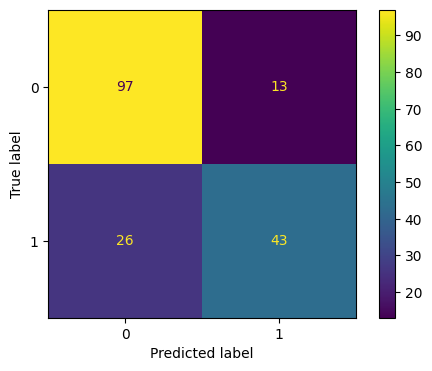

In [ ]:
# TODO 5: avalie o modelo no conjunto de teste
# - acurácia (accuracy_score)
# - matriz de confusão (confusion_matrix)
# - relatório de classificação (classification_report)
# - (opcional) ConfusionMatrixDisplay.from_predictions

# Acurácia
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusão:")
print(cm)

# Relatório de classificação
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

# Visualização da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

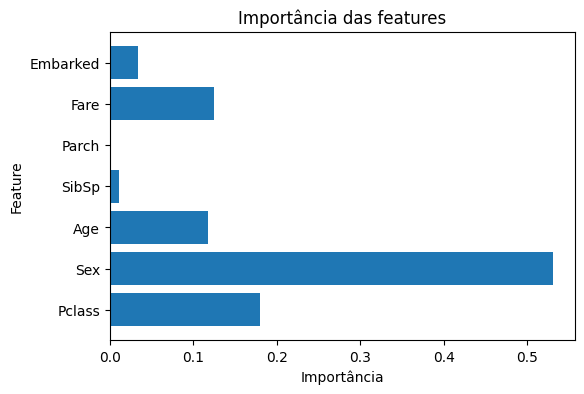

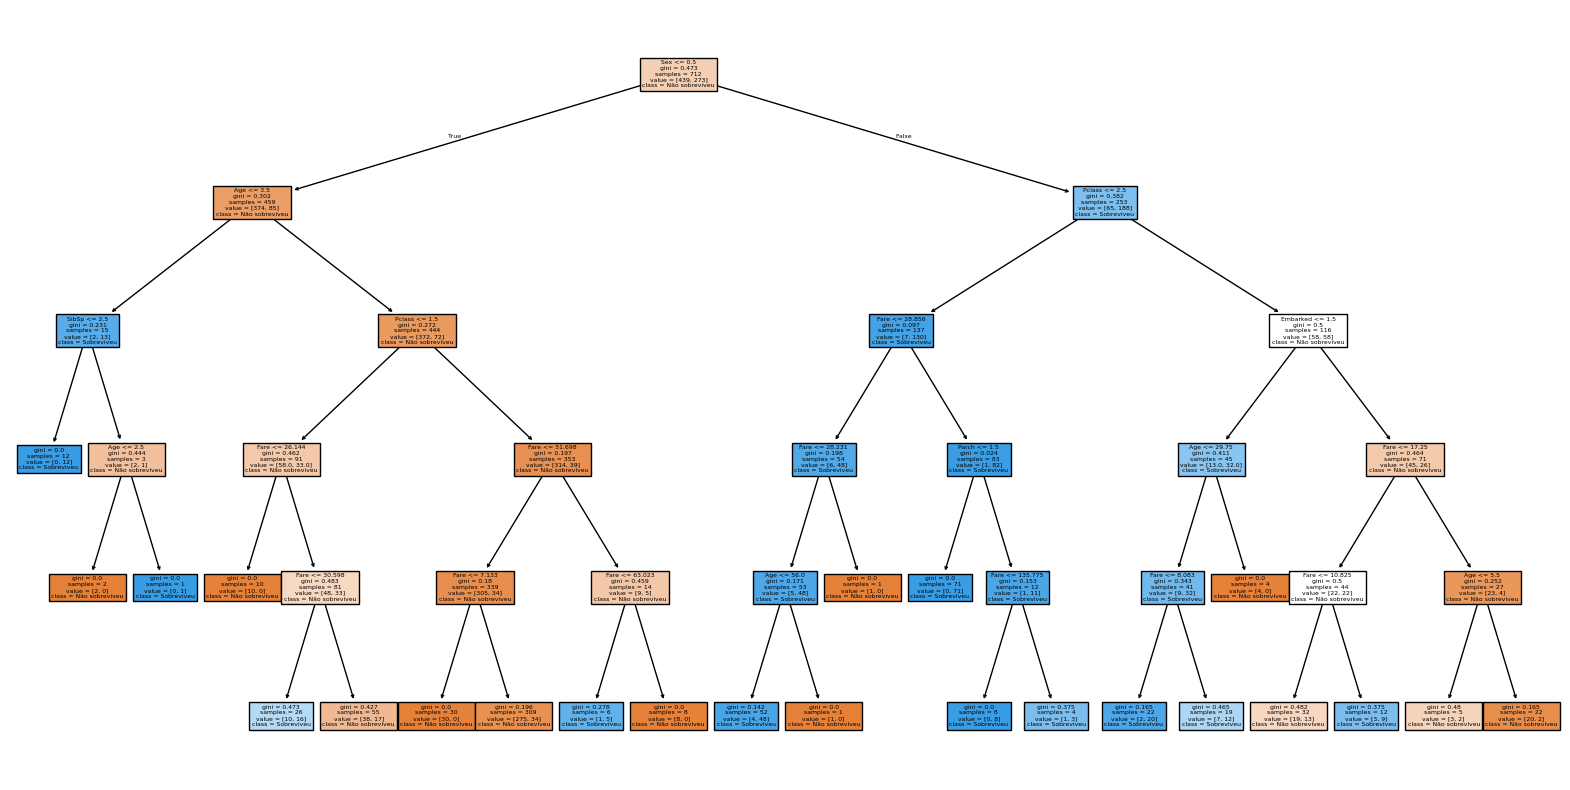

In [ ]:
# TODO 6: interprete o modelo
# - extraia model.feature_importances_ e plote (plt.barh)
# - (opcional) visualize a árvore com sklearn.tree.plot_tree

# Importância das features
importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Importância das features")
plt.show()

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Não sobreviveu', 'Sobreviveu'],
    filled=True
)

plt.show()

## 📝 Questões — Parte 2

1. Quais features foram as mais importantes para a árvore? Isso faz sentido historicamente?
as características como Sex, Pclass e Age. Elas são coerentes com o contexto histórico do naufrágio pois ha diferenças nas taxas de sobrevivência entre homens e mulheres e entre as diferentes classes de passageiros.

2. O que acontece com a acurácia quando você aumenta muito `max_depth`? E o risco de *overfitting*?
Quando max_depth aumenta, a árvore pode criar regras cada vez mais específicas para os dados de treinamento e a acurácia pode aumentar e se a árvore ficar muito profunda, ela pode começar a memorizar características específicas dos dados de treinamento. Isso aumenta o risco de overfitting, fazendo com que o modelo tenha um desempenho pior em dados novos.

3. Como você melhoraria o modelo? (ex.: criar novas features, tratar `Age` de outra forma, usar *random forest*, etc.)
criar novas features, como FamilySize, cr5iar novas faixas etárias, uytilizar novas técnicas de validação cruzada.

4. Compare a Árvore de Decisão com o Perceptron da Parte 1: quais as diferenças entre um modelo linear e um modelo baseado em árvore?
a Árvore de Decisão funciona criando uma sequência de regras de decisão e consegue representar relações não lineares entre as características. Já o perceptron é para problemas mais simples de fácil separação.

## 🎓 Conclusão

- O **Perceptron** é um modelo linear simples, bom para problemas **linearmente separáveis**.
- A **Árvore de Decisão** aprende regras *não lineares* e é **interpretável**, mas pode sofrer *overfitting*.
- O pré-processamento (valores ausentes e codificação de categóricas) é fundamental antes de treinar qualquer modelo.

Bons estudos! 🚀